In [18]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 25
day = 25

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

optimal travel lag is 5.755755755755757 cm based on kde of travel at max spatial information
using travel lag of 5.755755755755757 cm
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region PAR qualifies for spatial cells
brain region VISpl2/3 is disqualifying for spatial cells
brain region VISpl2/3 is disqualifying for s

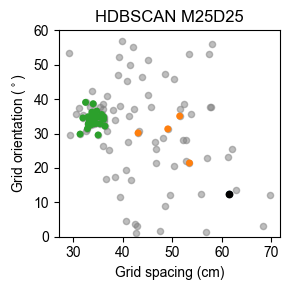

for module 0, there are 4 cells with average spacing 49.309763703448695
for module 1, there are 28 cells with average spacing 34.160627829333954
25 25
for module 1, there are 28 cells
for module 1, there are 28 cells
for module 0, there are 4 cells
for module 0, there are 4 cells
plotting vr rate maps using cluster_ids [3, 14, 15, 69, 71, 76, 83, 87, 91, 96, 101, 104, 105, 109, 111, 120, 207, 214, 215, 219, 221, 227, 230, 231, 232, 233, 234, 235]
plotting vr rate maps using cluster_ids [3, 14, 15, 69, 71, 76, 83, 87, 91, 96, 101, 104, 105, 109, 111, 120, 207, 214, 215, 219, 221, 227, 230, 231, 232, 233, 234, 235]


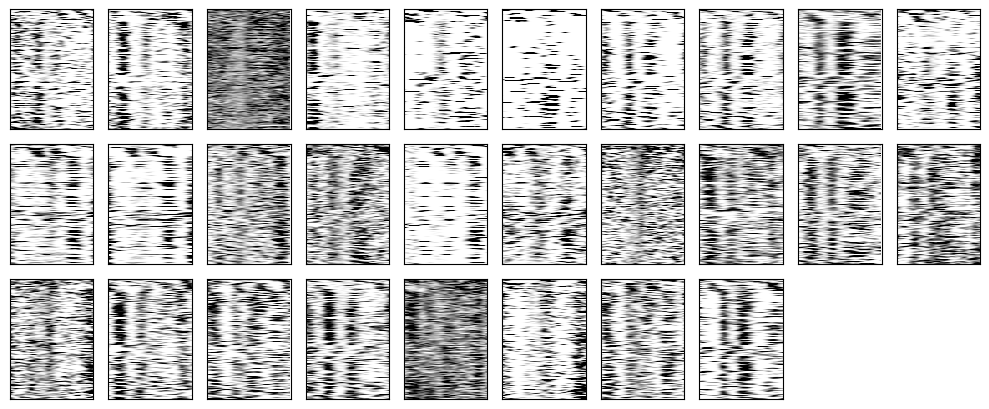

plotting vr rate maps using cluster_ids [11, 106, 209, 293]


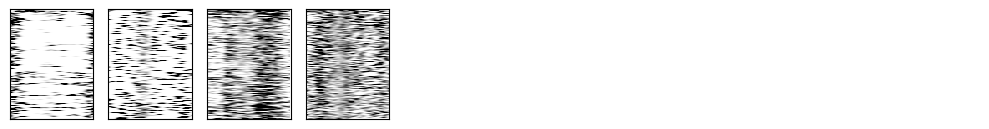

plotting vr rate maps using cluster_ids [1, 13, 16, 17, 32, 72, 73, 79, 80, 82, 85, 88, 89, 95, 97, 102, 110, 112, 123, 127, 169, 172, 173, 174, 175, 176, 177, 178, 179, 185, 186, 189, 191, 193, 196, 197, 198, 199, 202, 203, 205, 206, 210, 217, 220, 222, 225, 228, 229, 280, 281, 283, 284, 285, 287, 297]


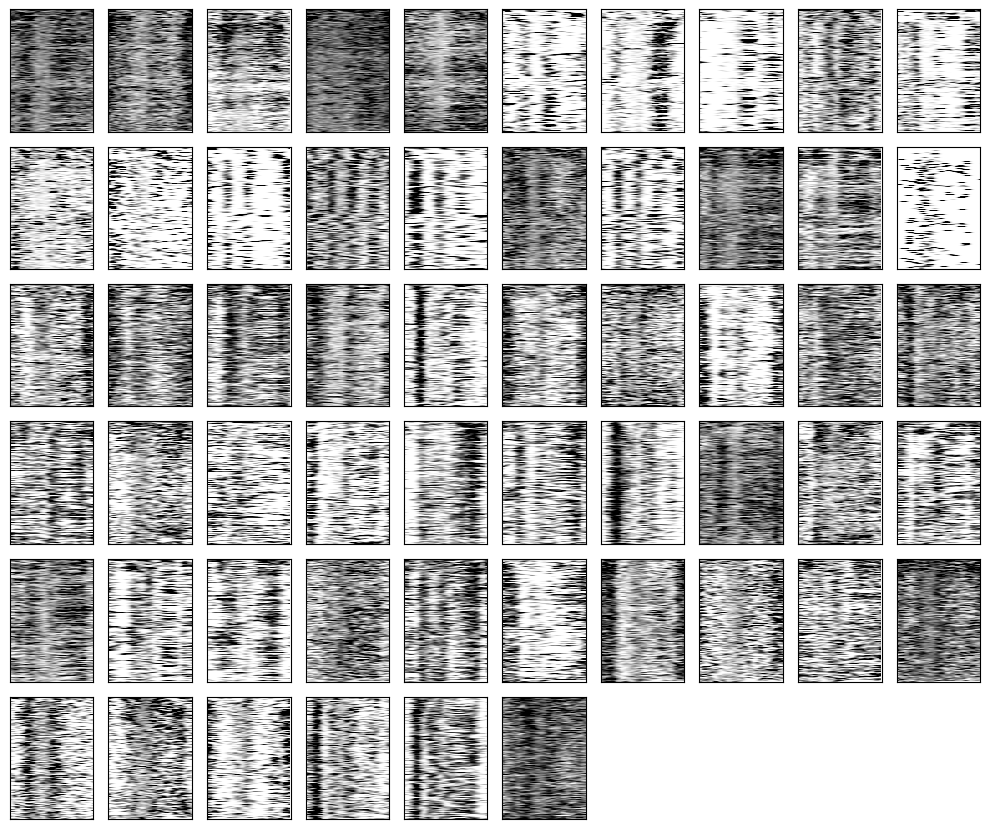

plotting vr rate maps using cluster_ids [8, 9, 10, 30, 31, 90, 92, 100, 117, 180, 181, 183, 188, 204, 211, 224, 288, 291, 295]


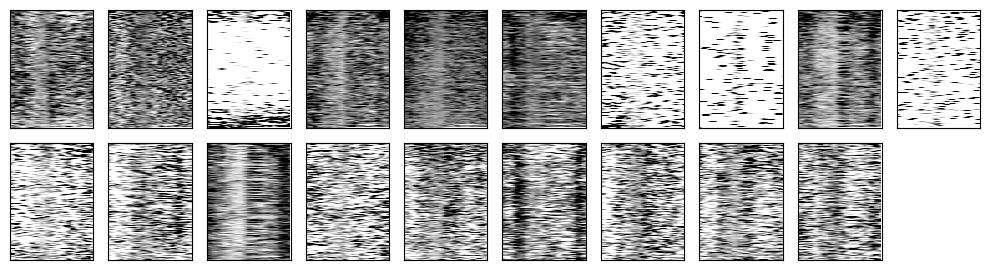

plotting vr rate maps using cluster_ids [3, 11, 14, 15, 69, 71, 76, 83, 87, 91, 96, 101, 104, 105, 106, 109, 111, 120, 170, 207, 209, 214, 215, 219, 221, 227, 230, 231, 232, 233, 234, 235, 293]


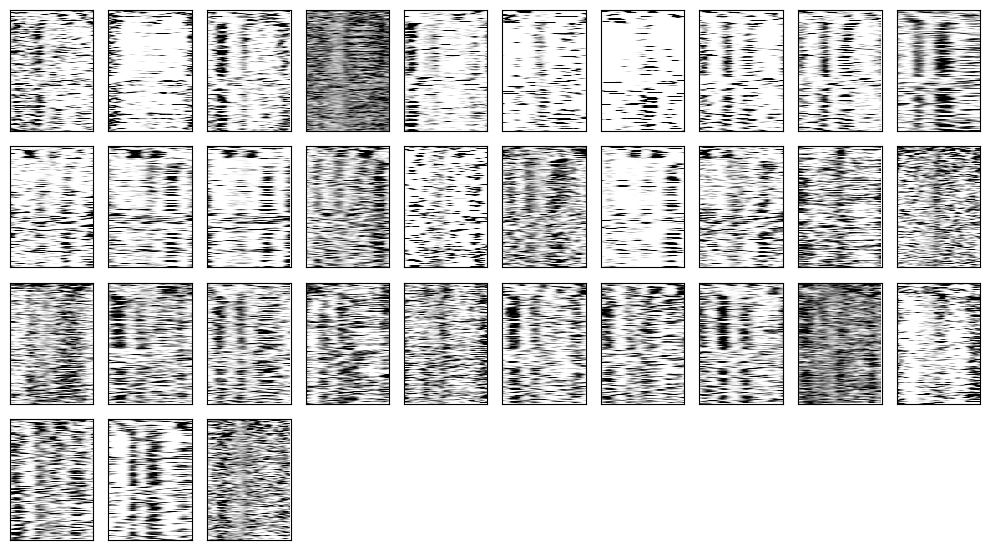

plotting vr rate maps using cluster_ids []
plotting vr rate maps using cluster_ids [11 106 170 209 293]


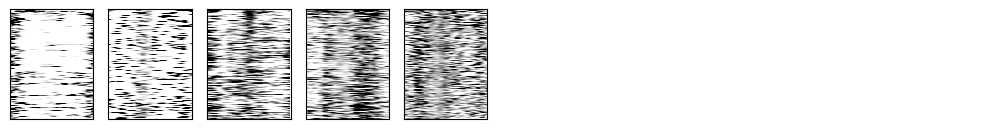

In [20]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
rc, rsc, vr_ns = cell_classification_vr(mouse, day)
mec, para, pre, sub, vis, cere, other, all_by_anatomy = cell_classification_anatomy(mouse, day)
g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)

plot_vr_rate_maps(mouse, day, np.setdiff1d(gcs.cluster_id.values, g_m_cluster_ids[0]), label=f'nocomodular_grid_cells', figpath=fig_path)

In [21]:
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)
tcs_of, tcs_time_of, beh_of, clusters_of, ep_OF = compute_of_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False, optimal_shift=gcs.travel[0])
last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

# time binned variables for later
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
pos_in_time = dt_in_time%tl
trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

x_pos_in_time_OF = np.array(beh_of['head_x'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep_OF))
y_pos_in_time_OF = np.array(beh_of['head_y'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep_OF))

if np.any(np.isnan(pos_in_time)):
    series = pd.Series(dt_in_time)
    filled_series = series.ffill().bfill()
    dt_in_time = np.array(filled_series)
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(speed_in_time)):
    series = pd.Series(speed_in_time)
    filled_series = series.ffill().bfill()
    speed_in_time = np.array(speed_in_time)

if np.any(np.isnan(x_pos_in_time_OF)):
    series = pd.Series(x_pos_in_time_OF)
    filled_series = series.ffill().bfill()
    x_pos_in_time_OF = np.array(filled_series)

if np.any(np.isnan(y_pos_in_time_OF)):
    series = pd.Series(y_pos_in_time_OF)
    filled_series = series.ffill().bfill()
    y_pos_in_time_OF = np.array(filled_series)

In [22]:
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = 1000)

In [23]:
test_grid_cell_1 = 91  # gc
test_grid_cell_2 = 235  # gc

import random

# Prepare grid predictors (remove test cells if present, then shuffle and select 10)
grid_predictors = g_m_cluster_ids[0].copy()
for test_id in [test_grid_cell_1, test_grid_cell_2]:
    if test_id in grid_predictors:
        grid_predictors.remove(test_id)
random.shuffle(grid_predictors)

# Prepare NGS predictors (remove test cells if present, then shuffle and select 10)
ngs_predictors = ngs.cluster_id.values.tolist()
for test_id in [test_grid_cell_1, test_grid_cell_2]:
    if test_id in ngs_predictors:
        ngs_predictors.remove(test_id)
random.shuffle(ngs_predictors)


In [24]:
def predict_xgboost_traces(
    target_id,
    tcs_time,
    pos_in_time,
    grid_predictors,
    ngs_predictors,
    coord_SCs_x_dict,  # dict: cluster_id -> coord_SCs_x
    xgb_history,
    gaussian_filter_nan
):
    """
    Predicts activity for a target cell using XGBoost with various covariate sets (medial/lateral).
    Returns a dictionary of predictions and cross-validated pR2 values.
    """
    y = np.array(tcs_time[target_id])
    y_smoothed = gaussian_filter_nan(y, sigma=3)

    # Split grid and NGS predictors into medial/lateral
    grid_medial = [cid for cid in grid_predictors if coord_SCs_x_dict.get(cid, 0) < 3400]
    grid_lateral = [cid for cid in grid_predictors if coord_SCs_x_dict.get(cid, 0) >= 3400]
    ngs_medial = [cid for cid in ngs_predictors if coord_SCs_x_dict.get(cid, 0) < 3400]
    ngs_lateral = [cid for cid in ngs_predictors if coord_SCs_x_dict.get(cid, 0) >= 3400]

    print(f"Number of medial grid cells: {len(grid_medial)}")
    print(f"Number of lateral grid cells: {len(grid_lateral)}")
    print(f"Number of medial NGS cells: {len(ngs_medial)}")
    print(f"Number of lateral NGS cells: {len(ngs_lateral)}")

    # --- POSITION ONLY ---
    Xpos = np.stack([pos_in_time]).T

    results = {}
    # Position only
    results['pos'] = xgb_history.fit_cv(Xpos, y, verbose=0, continuous_folds=True)
    pr2 = np.nanmean(results['pos'][1]) if isinstance(results['pos'], (list, tuple)) and len(results['pos']) > 1 else None
    print(f"Covariate: pos, pR2: {pr2:.4f}")

    # --- GRID CELLS ---
    if grid_medial:
        Xg_medial = np.column_stack([np.array(tcs_time[cid]) for cid in grid_medial])
        Xpos_g_medial = np.column_stack((pos_in_time, Xg_medial))
        results['g_medial'] = xgb_history.fit_cv(Xg_medial, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['g_medial'][1]) if isinstance(results['g_medial'], (list, tuple)) and len(results['g_medial']) > 1 else None
        print(f"Covariate: g_medial, pR2: {pr2:.4f}")
        results['pos_g_medial'] = xgb_history.fit_cv(Xpos_g_medial, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['pos_g_medial'][1]) if isinstance(results['pos_g_medial'], (list, tuple)) and len(results['pos_g_medial']) > 1 else None
        print(f"Covariate: pos_g_medial, pR2: {pr2:.4f}")
    else:
        print("No grid_medial predictors available for this cell. Filling with NaNs.")
        results['g_medial'] = (np.full_like(y, np.nan), [np.nan])
        results['pos_g_medial'] = (np.full_like(y, np.nan), [np.nan])

    if grid_lateral:
        Xg_lateral = np.column_stack([np.array(tcs_time[cid]) for cid in grid_lateral])
        Xpos_g_lateral = np.column_stack((pos_in_time, Xg_lateral))
        results['g_lateral'] = xgb_history.fit_cv(Xg_lateral, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['g_lateral'][1]) if isinstance(results['g_lateral'], (list, tuple)) and len(results['g_lateral']) > 1 else None
        print(f"Covariate: g_lateral, pR2: {pr2:.4f}")
        results['pos_g_lateral'] = xgb_history.fit_cv(Xpos_g_lateral, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['pos_g_lateral'][1]) if isinstance(results['pos_g_lateral'], (list, tuple)) and len(results['pos_g_lateral']) > 1 else None
        print(f"Covariate: pos_g_lateral, pR2: {pr2:.4f}")
    else:
        print("No grid_lateral predictors available for this cell. Filling with NaNs.")
        results['g_lateral'] = (np.full_like(y, np.nan), [np.nan])
        results['pos_g_lateral'] = (np.full_like(y, np.nan), [np.nan])

    # --- NGS CELLS ---
    if ngs_medial:
        Xngs_medial = np.column_stack([np.array(tcs_time[cid]) for cid in ngs_medial])
        Xpos_ngs_medial = np.column_stack((pos_in_time, Xngs_medial))
        results['ngs_medial'] = xgb_history.fit_cv(Xngs_medial, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['ngs_medial'][1]) if isinstance(results['ngs_medial'], (list, tuple)) and len(results['ngs_medial']) > 1 else None
        print(f"Covariate: ngs_medial, pR2: {pr2:.4f}")
        results['pos_ngs_medial'] = xgb_history.fit_cv(Xpos_ngs_medial, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['pos_ngs_medial'][1]) if isinstance(results['pos_ngs_medial'], (list, tuple)) and len(results['pos_ngs_medial']) > 1 else None
        print(f"Covariate: pos_ngs_medial, pR2: {pr2:.4f}")
    else:
        print("No ngs_medial predictors available for this cell. Filling with NaNs.")
        results['ngs_medial'] = (np.full_like(y, np.nan), [np.nan])
        results['pos_ngs_medial'] = (np.full_like(y, np.nan), [np.nan])

    if ngs_lateral:
        Xngs_lateral = np.column_stack([np.array(tcs_time[cid]) for cid in ngs_lateral])
        Xpos_ngs_lateral = np.column_stack((pos_in_time, Xngs_lateral))
        results['ngs_lateral'] = xgb_history.fit_cv(Xngs_lateral, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['ngs_lateral'][1]) if isinstance(results['ngs_lateral'], (list, tuple)) and len(results['ngs_lateral']) > 1 else None
        print(f"Covariate: ngs_lateral, pR2: {pr2:.4f}")
        results['pos_ngs_lateral'] = xgb_history.fit_cv(Xpos_ngs_lateral, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['pos_ngs_lateral'][1]) if isinstance(results['pos_ngs_lateral'], (list, tuple)) and len(results['pos_ngs_lateral']) > 1 else None
        print(f"Covariate: pos_ngs_lateral, pR2: {pr2:.4f}")
    else:
        print("No ngs_lateral predictors available for this cell. Filling with NaNs.")
        results['ngs_lateral'] = (np.full_like(y, np.nan), [np.nan])
        results['pos_ngs_lateral'] = (np.full_like(y, np.nan), [np.nan])

    results['y'] = y
    results['y_smoothed'] = y_smoothed
    return results

In [25]:
def plot_xgboost_traces(
    results_dict,
    target_cell_names,
    covariate_labels,
    tidy_covariate_labels=None,
    true_labels=['y', 'y_smoothed'],
    window=None,
    figsize=(15, 4),
    gain=[1,1,1],
    text_offset=0.0,
    offset_jump=0.0,
    savepath=None,
    time_bs=100
):
    """
    Plot true and predicted traces for target cells side by side (3 columns) using results_dict directly.
    Each covariate prediction is offset vertically for clarity.
    true_labels are plotted at the top, overlayed, in black and grey (same offset).
    Covariate label on left, mean pR2 on right. No axes.
    Offsets are fixed and identical across all subplots.
    Colors: test_grid_cell_1 and test_grid_cell_2 = red, test_ngs_cell_1 = blue.
    text_offset: float, controls vertical shift of all text annotations (in units of offset_step).
    offset_jump: float, additional offset (in units of offset_step) between y/pos and pos_g10/ngs1.
    tidy_covariate_labels: list of strings, used for text on the figure (with n=x as subscript).
    """
    import matplotlib.pyplot as plt
    import numpy as np

    print("plot_xgboost_traces: Start plotting")
    print(f"Target cells: {target_cell_names}")
    print(f"Covariate labels: {covariate_labels}")
    print(f"Results dict keys for each cell:")
    for cell in target_cell_names:
        print(f"  {cell}: {list(results_dict[cell].keys())}")

    # Helper to convert "n=x" to subscript in label
    def subscript_n(label):
        import re
        # Replace n=number with $_{n=number}$ for subscript
        return re.sub(r'n=([0-9]+)', r'$_{n=\\1}$', label)

    # Order: true_labels (same offset), then covariate_labels in the order provided
    ordered_labels = [true_labels[0]] + list(covariate_labels)
    n_offsets = len(ordered_labels)

    print(f"Ordered labels for plotting: {ordered_labels}")
    print(f"Number of offsets: {n_offsets}")

    # Compute a global offset step based on all traces
    all_true_traces = [results_dict[cell]["y"] for cell in target_cell_names]
    if window is not None:
        all_true_traces = [trace[window[0]:window[1]] for trace in all_true_traces]
    global_max = np.nanmax([np.nanmax(trace) for trace in all_true_traces])
    offset_step = global_max * 1.2 if global_max > 0 else 1

    # Build offsets with jumps
    offsets = []
    for i, label in enumerate(ordered_labels):
        # Add offset_jump after y (true_labels)
        jump = 0
        if i == 1:  # after y/true_labels
            jump = offset_jump * offset_step
        if i == 0:
            offsets.append(offset_step * (n_offsets - 1 - i))
        else:
            offsets.append(offsets[-1] - offset_step - jump)

    # Assign colors by test cell: red for grid cells, blue for ngs
    color_map_by_cell = {}
    for cell_name in target_cell_names:
        if '340' in str(cell_name).lower():
            color_map_by_cell[cell_name] = '#3171ae'
        else:
            color_map_by_cell[cell_name] = '#c04744'
    # True label colors
    true_label_colors = ['grey', 'black']

    n_cells = len(target_cell_names)
    fig, axes = plt.subplots(1, n_cells, figsize=figsize, sharey=True)
    if n_cells == 1:
        axes = [axes]
    for i, cell_name in enumerate(target_cell_names):
        ax = axes[i]
        true_trace = results_dict[cell_name]["y"]
        if window is not None:
            t_idx = np.arange(window[0], window[1])
            true_trace = true_trace[window[0]:window[1]]
        else:
            t_idx = np.arange(len(true_trace))
        # Plot true labels at the top, overlayed, with same offset
        true_offset = offsets[0]
        for j, label in enumerate(true_labels):
            if label in results_dict[cell_name]:
                trace = results_dict[cell_name][label]
                if window is not None:
                    trace = trace[window[0]:window[1]]
                ax.plot(t_idx, trace * 2 + true_offset, lw=2, color=true_label_colors[j], alpha=0.8)
                # Add label to left, move up by text_offset*offset_step
                if i == 0:
                    ax.text(
                        t_idx[0] - (0.01 * len(t_idx)),
                        np.nanmean(trace * 2 + true_offset) + text_offset * offset_step,
                        label,
                        color=true_label_colors[j],
                        va='center',
                        ha='right',
                        fontsize=15
                    )
        # Plot predictions for each covariate set with fixed vertical offsets
        for j, cov_label in enumerate(covariate_labels):
            idx = ordered_labels.index(cov_label)
            if cov_label not in results_dict[cell_name]:
                print(f"WARNING: Covariate '{cov_label}' missing for cell {cell_name}. Skipping this trace.")
                continue
            pred_trace = results_dict[cell_name][cov_label][0]
            if window is not None:
                pred_trace = pred_trace[window[0]:window[1]]
            pr2 = np.nanmean(results_dict[cell_name][cov_label][1])
            color = color_map_by_cell[cell_name]
            offset = offsets[idx]
            # Use tidy label with subscript
            tidy_label = tidy_covariate_labels[j] if tidy_covariate_labels else cov_label
            tidy_label = subscript_n(tidy_label)

            # Determine number of cells used for this covariate
            n_cells = None
            # Heuristic: check if covariate label contains 'g_medial', 'g_lateral', etc.
            if 'g_medial' in cov_label:
                n_cells = sum([coord_SCs_x_dict.get(cid, 0) < 3400 for cid in grid_predictors])
            elif 'g_lateral' in cov_label:
                n_cells = sum([coord_SCs_x_dict.get(cid, 0) >= 3400 for cid in grid_predictors])
            elif 'ngs_medial' in cov_label:
                n_cells = sum([coord_SCs_x_dict.get(cid, 0) < 3400 for cid in ngs_predictors])
            elif 'ngs_lateral' in cov_label:
                n_cells = sum([coord_SCs_x_dict.get(cid, 0) >= 3400 for cid in ngs_predictors])
            else:
                n_cells = ''

            pr2_label = f"{pr2:.2f}"

            ax.plot(t_idx, pred_trace * gain[i] + offset, lw=1.5, alpha=0.8, color=color)
            # Add covariate label to left, move up by text_offset*offset_step
            if i == 0:
                ax.text(
                    t_idx[0] - (0.01 * len(t_idx)),
                    np.nanmean(pred_trace + offset) + text_offset * offset_step,
                    tidy_label,
                    color=color,
                    va='center',
                    ha='right',
                    fontsize=15,
                )
            # Add mean pR2 and n_cells to right, move up by text_offset*offset_step
            ax.text(
                t_idx[-1] + (0.01 * len(t_idx)),
                np.nanmean(pred_trace + offset) + text_offset * offset_step,
                pr2_label,
                color=color,
                va='center',
                ha='left',
                fontsize=10,
            )
        ax.set_title(f"Unit {cell_name}", fontsize=16)
        # Remove axes
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis('off')
        # plot a line to show 5 seconds
    axes[-1].plot([window[0], window[0] + 5000/time_bs], [offsets[-1], offsets[-1]], color='black', lw=2)
    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath)
    plt.show()
    print("plot_xgboost_traces: Finished plotting")

In [33]:
def predict_xgboost_traces(
    target_id,
    tcs_time,
    pos_in_time,
    grid_predictors,
    ngs_predictors,
    coord_SCs_x_dict,      # dict: cluster_id -> coord_SCs_x
    xgb_history,
    gaussian_filter_nan,
    ngs_grid_score_dict=None,  # dict: NGS cluster_id -> grid_score
):
    """
    Predicts activity for a target cell using XGBoost with various covariate sets
    (medial/lateral, grid and NGS).

    Optionally also constructs grid-score–matched medial and lateral NGS
    covariates if `ngs_grid_score_dict` is provided, and plots histograms
    of the grid-score distributions before/after trimming and matching.
    """
    y = np.array(tcs_time[target_id])
    y_smoothed = gaussian_filter_nan(y, sigma=3)

    # Split grid and NGS predictors into medial/lateral
    grid_medial = [cid for cid in grid_predictors if coord_SCs_x_dict.get(cid, 0) < 3400]
    grid_lateral = [cid for cid in grid_predictors if coord_SCs_x_dict.get(cid, 0) >= 3400]
    ngs_medial = [cid for cid in ngs_predictors if coord_SCs_x_dict.get(cid, 0) < 3400]
    ngs_lateral = [cid for cid in ngs_predictors if coord_SCs_x_dict.get(cid, 0) >= 3400]

    print(f"Number of medial grid cells: {len(grid_medial)}")
    print(f"Number of lateral grid cells: {len(grid_lateral)}")
    print(f"Number of medial NGS cells: {len(ngs_medial)}")
    print(f"Number of lateral NGS cells: {len(ngs_lateral)}")

    # --- POSITION ONLY ---
    Xpos = np.stack([pos_in_time]).T

    results = {}
    # Position only
    results['pos'] = xgb_history.fit_cv(Xpos, y, verbose=0, continuous_folds=True)
    pr2 = np.nanmean(results['pos'][1]) if isinstance(results['pos'], (list, tuple)) and len(results['pos']) > 1 else None
    if pr2 is not None:
        print(f"Covariate: pos, pR2: {pr2:.4f}")
    else:
        print("Covariate: pos, pR2: None")

    # --- GRID CELLS ---
    if grid_medial:
        Xg_medial = np.column_stack([np.array(tcs_time[cid]) for cid in grid_medial])
        Xpos_g_medial = np.column_stack((pos_in_time, Xg_medial))
        results['g_medial'] = xgb_history.fit_cv(Xg_medial, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['g_medial'][1]) if isinstance(results['g_medial'], (list, tuple)) and len(results['g_medial']) > 1 else None
        if pr2 is not None:
            print(f"Covariate: g_medial, pR2: {pr2:.4f}")
        results['pos_g_medial'] = xgb_history.fit_cv(Xpos_g_medial, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['pos_g_medial'][1]) if isinstance(results['pos_g_medial'], (list, tuple)) and len(results['pos_g_medial']) > 1 else None
        if pr2 is not None:
            print(f"Covariate: pos_g_medial, pR2: {pr2:.4f}")
    else:
        print("No grid_medial predictors available for this cell. Filling with NaNs.")
        results['g_medial'] = (np.full_like(y, np.nan), [np.nan])
        results['pos_g_medial'] = (np.full_like(y, np.nan), [np.nan])

    if grid_lateral:
        Xg_lateral = np.column_stack([np.array(tcs_time[cid]) for cid in grid_lateral])
        Xpos_g_lateral = np.column_stack((pos_in_time, Xg_lateral))
        results['g_lateral'] = xgb_history.fit_cv(Xg_lateral, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['g_lateral'][1]) if isinstance(results['g_lateral'], (list, tuple)) and len(results['g_lateral']) > 1 else None
        if pr2 is not None:
            print(f"Covariate: g_lateral, pR2: {pr2:.4f}")
        results['pos_g_lateral'] = xgb_history.fit_cv(Xpos_g_lateral, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['pos_g_lateral'][1]) if isinstance(results['pos_g_lateral'], (list, tuple)) and len(results['pos_g_lateral']) > 1 else None
        if pr2 is not None:
            print(f"Covariate: pos_g_lateral, pR2: {pr2:.4f}")
    else:
        print("No grid_lateral predictors available for this cell. Filling with NaNs.")
        results['g_lateral'] = (np.full_like(y, np.nan), [np.nan])
        results['pos_g_lateral'] = (np.full_like(y, np.nan), [np.nan])

    # --- NGS CELLS ---
    if ngs_medial:
        Xngs_medial = np.column_stack([np.array(tcs_time[cid]) for cid in ngs_medial])
        Xpos_ngs_medial = np.column_stack((pos_in_time, Xngs_medial))
        results['ngs_medial'] = xgb_history.fit_cv(Xngs_medial, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['ngs_medial'][1]) if isinstance(results['ngs_medial'], (list, tuple)) and len(results['ngs_medial']) > 1 else None
        if pr2 is not None:
            print(f"Covariate: ngs_medial, pR2: {pr2:.4f}")
        results['pos_ngs_medial'] = xgb_history.fit_cv(Xpos_ngs_medial, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['pos_ngs_medial'][1]) if isinstance(results['pos_ngs_medial'], (list, tuple)) and len(results['pos_ngs_medial']) > 1 else None
        if pr2 is not None:
            print(f"Covariate: pos_ngs_medial, pR2: {pr2:.4f}")
    else:
        print("No ngs_medial predictors available for this cell. Filling with NaNs.")
        results['ngs_medial'] = (np.full_like(y, np.nan), [np.nan])
        results['pos_ngs_medial'] = (np.full_like(y, np.nan), [np.nan])

    if ngs_lateral:
        Xngs_lateral = np.column_stack([np.array(tcs_time[cid]) for cid in ngs_lateral])
        Xpos_ngs_lateral = np.column_stack((pos_in_time, Xngs_lateral))
        results['ngs_lateral'] = xgb_history.fit_cv(Xngs_lateral, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['ngs_lateral'][1]) if isinstance(results['ngs_lateral'], (list, tuple)) and len(results['ngs_lateral']) > 1 else None
        if pr2 is not None:
            print(f"Covariate: ngs_lateral, pR2: {pr2:.4f}")
        results['pos_ngs_lateral'] = xgb_history.fit_cv(Xpos_ngs_lateral, y, verbose=0, continuous_folds=True)
        pr2 = np.nanmean(results['pos_ngs_lateral'][1]) if isinstance(results['pos_ngs_lateral'], (list, tuple)) and len(results['pos_ngs_lateral']) > 1 else None
        if pr2 is not None:
            print(f"Covariate: pos_ngs_lateral, pR2: {pr2:.4f}")
    else:
        print("No ngs_lateral predictors available for this cell. Filling with NaNs.")
        results['ngs_lateral'] = (np.full_like(y, np.nan), [np.nan])
        results['pos_ngs_lateral'] = (np.full_like(y, np.nan), [np.nan])

    # --- GRID-SCORE–MATCHED NGS COVARIATES + HISTOGRAMS ---
    matched_ngs_medial = []
    matched_ngs_lateral = []

    if (ngs_grid_score_dict is not None) and ngs_medial and ngs_lateral:
        # Build (cid, grid_score) lists and drop any without a valid score
        def _scored_list(cids, score_dict):
            scored = []
            for cid in cids:
                s = score_dict.get(cid, np.nan)
                if s is None or np.isnan(s):
                    continue
                scored.append((cid, float(s)))
            return scored

        medial_scored = _scored_list(ngs_medial, ngs_grid_score_dict)
        lateral_scored = _scored_list(ngs_lateral, ngs_grid_score_dict)

        if medial_scored and lateral_scored:
            # ----- 1) Histograms of ALL NGS grid scores (before any trimming) -----
            medial_scores_all = np.array([s for _, s in medial_scored])
            lateral_scores_all = np.array([s for _, s in lateral_scored])

            plt.figure(figsize=(6, 3))
            bins = np.linspace(
                np.nanmin([medial_scores_all.min(), lateral_scores_all.min()]),
                np.nanmax([medial_scores_all.max(), lateral_scores_all.max()]),
                20,
            )
            plt.hist(medial_scores_all, bins=bins, alpha=0.6,
                     label='NGS medial (all)', color='#c04744')
            plt.hist(lateral_scores_all, bins=bins, alpha=0.6,
                     label='NGS lateral (all)', color='#4a7bb7')
            plt.xlabel('Grid score')
            plt.ylabel('Count')
            plt.title('NGS grid-score distributions (all)')
            plt.legend(frameon=False)
            plt.tight_layout()
            plt.show()

            # ----- 2) Trim to overlapping grid-score range -----
            overlap_min = max(medial_scores_all.min(), lateral_scores_all.min())
            overlap_max = min(medial_scores_all.max(), lateral_scores_all.max())

            medial_trimmed = [(cid, s) for cid, s in medial_scored
                              if overlap_min <= s <= overlap_max]
            lateral_trimmed = [(cid, s) for cid, s in lateral_scored
                               if overlap_min <= s <= overlap_max]

            print(f"Overlapping grid-score range: [{overlap_min:.3f}, {overlap_max:.3f}]")
            print(f"Medial NGS: {len(medial_scored)} -> {len(medial_trimmed)} after trimming")
            print(f"Lateral NGS: {len(lateral_scored)} -> {len(lateral_trimmed)} after trimming")

            if medial_trimmed and lateral_trimmed:
                # Optional: histogram of TRIMMED distributions
                medial_scores_trim = np.array([s for _, s in medial_trimmed])
                lateral_scores_trim = np.array([s for _, s in lateral_trimmed])

                plt.figure(figsize=(6, 3))
                bins_trim = np.linspace(
                    np.nanmin([medial_scores_trim.min(), lateral_scores_trim.min()]),
                    np.nanmax([medial_scores_trim.max(), lateral_scores_trim.max()]),
                    20,
                )
                plt.hist(medial_scores_trim, bins=bins_trim, alpha=0.6,
                         label='NGS medial (trimmed)', color='#c04744')
                plt.hist(lateral_scores_trim, bins=bins_trim, alpha=0.6,
                         label='NGS lateral (trimmed)', color='#4a7bb7')
                plt.xlabel('Grid score')
                plt.ylabel('Count')
                plt.title('NGS grid-score distributions (trimmed to overlap)')
                plt.legend(frameon=False)
                plt.tight_layout()
                plt.show()

                # ----- 3) Nearest-neighbour matching within overlapping range -----
                medial_trimmed.sort(key=lambda x: x[1])
                lateral_trimmed.sort(key=lambda x: x[1])

                # Always match from the smaller trimmed group into the larger trimmed group
                if len(medial_trimmed) <= len(lateral_trimmed):
                    small = medial_trimmed
                    big = lateral_trimmed
                    small_is_medial = True
                else:
                    small = lateral_trimmed
                    big = medial_trimmed
                    small_is_medial = False

                used_big = set()
                for cid_s, score_s in small:
                    best_cid = None
                    best_diff = np.inf
                    for cid_b, score_b in big:
                        if cid_b in used_big:
                            continue
                        diff = abs(score_b - score_s)
                        if diff < best_diff:
                            best_diff = diff
                            best_cid = cid_b
                    if best_cid is not None:
                        used_big.add(best_cid)
                        if small_is_medial:
                            matched_ngs_medial.append(cid_s)
                            matched_ngs_lateral.append(best_cid)
                        else:
                            matched_ngs_medial.append(best_cid)
                            matched_ngs_lateral.append(cid_s)

                print(
                    f"Grid-score matching (after trimming): "
                    f"{len(matched_ngs_medial)} medial and {len(matched_ngs_lateral)} lateral NGS cells matched."
                )

                # ----- 4) Histograms AFTER matching (only matched subsets) -----
                if matched_ngs_medial and matched_ngs_lateral:
                    matched_medial_scores = np.array(
                        [ngs_grid_score_dict[cid] for cid in matched_ngs_medial]
                    )
                    matched_lateral_scores = np.array(
                        [ngs_grid_score_dict[cid] for cid in matched_ngs_lateral]
                    )

                    plt.figure(figsize=(6, 3))
                    bins_matched = np.linspace(
                        np.nanmin([matched_medial_scores.min(), matched_lateral_scores.min()]),
                        np.nanmax([matched_medial_scores.max(), matched_lateral_scores.max()]),
                        20,
                    )
                    plt.hist(
                        matched_medial_scores,
                        bins=bins_matched,
                        alpha=0.6,
                        label='NGS medial (matched)',
                        color='#c04744',
                    )
                    plt.hist(
                        matched_lateral_scores,
                        bins=bins_matched,
                        alpha=0.6,
                        label='NGS lateral (matched)',
                        color='#4a7bb7',
                    )
                    plt.xlabel('Grid score')
                    plt.ylabel('Count')
                    plt.title('NGS grid-score distributions (matched subsets)')
                    plt.legend(frameon=False)
                    plt.tight_layout()
                    plt.show()
            else:
                print("After trimming to overlapping grid-score range, one side is empty; skipping matching.")
        else:
            print("Not enough NGS grid_score information to perform matching.")
    else:
        print("ngs_grid_score_dict not provided or too few NGS cells; skipping grid-score matching.")

    # Fit models using ONLY the grid-score–matched NGS subsets
    if matched_ngs_medial and matched_ngs_lateral:
        # Medial matched NGS
        Xngs_medial_matched = np.column_stack([np.array(tcs_time[cid]) for cid in matched_ngs_medial])
        Xpos_ngs_medial_matched = np.column_stack((pos_in_time, Xngs_medial_matched))
        results['ngs_medial_matched'] = xgb_history.fit_cv(
            Xngs_medial_matched, y, verbose=0, continuous_folds=True
        )
        pr2 = np.nanmean(results['ngs_medial_matched'][1]) if isinstance(results['ngs_medial_matched'], (list, tuple)) and len(results['ngs_medial_matched']) > 1 else None
        if pr2 is not None:
            print(f"Covariate: ngs_medial_matched, pR2: {pr2:.4f}")
        results['pos_ngs_medial_matched'] = xgb_history.fit_cv(
            Xpos_ngs_medial_matched, y, verbose=0, continuous_folds=True
        )
        pr2 = np.nanmean(results['pos_ngs_medial_matched'][1]) if isinstance(results['pos_ngs_medial_matched'], (list, tuple)) and len(results['pos_ngs_medial_matched']) > 1 else None
        if pr2 is not None:
            print(f"Covariate: pos_ngs_medial_matched, pR2: {pr2:.4f}")

        # Lateral matched NGS
        Xngs_lateral_matched = np.column_stack([np.array(tcs_time[cid]) for cid in matched_ngs_lateral])
        Xpos_ngs_lateral_matched = np.column_stack((pos_in_time, Xngs_lateral_matched))
        results['ngs_lateral_matched'] = xgb_history.fit_cv(
            Xngs_lateral_matched, y, verbose=0, continuous_folds=True
        )
        pr2 = np.nanmean(results['ngs_lateral_matched'][1]) if isinstance(results['ngs_lateral_matched'], (list, tuple)) and len(results['ngs_lateral_matched']) > 1 else None
        if pr2 is not None:
            print(f"Covariate: ngs_lateral_matched, pR2: {pr2:.4f}")
        results['pos_ngs_lateral_matched'] = xgb_history.fit_cv(
            Xpos_ngs_lateral_matched, y, verbose=0, continuous_folds=True
        )
        pr2 = np.nanmean(results['pos_ngs_lateral_matched'][1]) if isinstance(results['pos_ngs_lateral_matched'], (list, tuple)) and len(results['pos_ngs_lateral_matched']) > 1 else None
        if pr2 is not None:
            print(f"Covariate: pos_ngs_lateral_matched, pR2: {pr2:.4f}")
    else:
        # If no matches, fill matched covariates with NaNs
        results['ngs_medial_matched'] = (np.full_like(y, np.nan), [np.nan])
        results['pos_ngs_medial_matched'] = (np.full_like(y, np.nan), [np.nan])
        results['ngs_lateral_matched'] = (np.full_like(y, np.nan), [np.nan])
        results['pos_ngs_lateral_matched'] = (np.full_like(y, np.nan), [np.nan])

    results['y'] = y
    results['y_smoothed'] = y_smoothed
    return results

Built ngs_grid_score_dict for 56 NGS cells
Number of medial grid cells: 15
Number of lateral grid cells: 11
Number of medial NGS cells: 20
Number of lateral NGS cells: 36
Covariate: pos, pR2: 0.0312
Covariate: pos, pR2: 0.0312
Covariate: g_medial, pR2: 0.1254
Covariate: g_medial, pR2: 0.1254
Covariate: pos_g_medial, pR2: 0.1352
Covariate: pos_g_medial, pR2: 0.1352
Covariate: g_lateral, pR2: 0.0992
Covariate: g_lateral, pR2: 0.0992
Covariate: pos_g_lateral, pR2: 0.1141
Covariate: pos_g_lateral, pR2: 0.1141
Covariate: ngs_medial, pR2: 0.1481
Covariate: ngs_medial, pR2: 0.1481
Covariate: pos_ngs_medial, pR2: 0.1526
Covariate: pos_ngs_medial, pR2: 0.1526
Covariate: ngs_lateral, pR2: 0.0562
Covariate: ngs_lateral, pR2: 0.0562
Covariate: pos_ngs_lateral, pR2: 0.0632
Covariate: pos_ngs_lateral, pR2: 0.0632


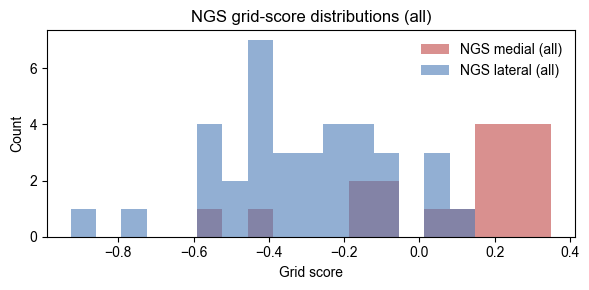

Overlapping grid-score range: [-0.584, 0.101]
Medial NGS: 20 -> 7 after trimming
Lateral NGS: 36 -> 34 after trimming


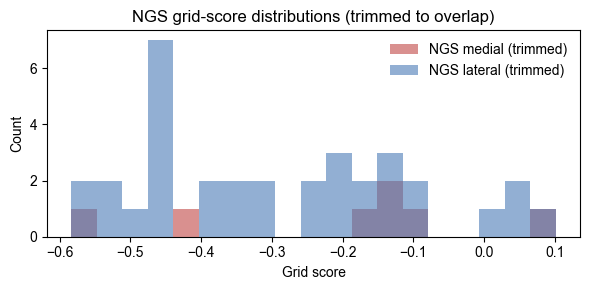

Grid-score matching (after trimming): 7 medial and 7 lateral NGS cells matched.


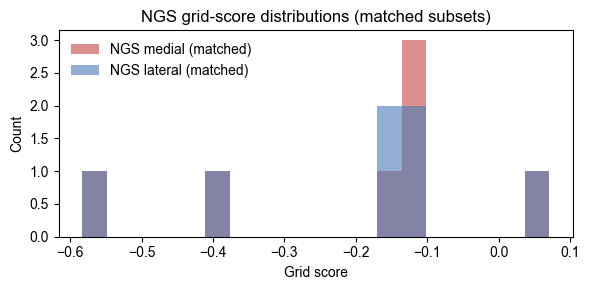

Covariate: ngs_medial_matched, pR2: 0.0778
Covariate: pos_ngs_medial_matched, pR2: 0.0910
Covariate: pos_ngs_medial_matched, pR2: 0.0910
Covariate: ngs_lateral_matched, pR2: 0.0242
Covariate: ngs_lateral_matched, pR2: 0.0242
Covariate: pos_ngs_lateral_matched, pR2: 0.0454
Number of medial grid cells: 15
Number of lateral grid cells: 11
Number of medial NGS cells: 20
Number of lateral NGS cells: 36
Covariate: pos_ngs_lateral_matched, pR2: 0.0454
Number of medial grid cells: 15
Number of lateral grid cells: 11
Number of medial NGS cells: 20
Number of lateral NGS cells: 36
Covariate: pos, pR2: 0.0346
Covariate: pos, pR2: 0.0346
Covariate: g_medial, pR2: 0.1082
Covariate: g_medial, pR2: 0.1082
Covariate: pos_g_medial, pR2: 0.1160
Covariate: pos_g_medial, pR2: 0.1160
Covariate: g_lateral, pR2: 0.0973
Covariate: g_lateral, pR2: 0.0973
Covariate: pos_g_lateral, pR2: 0.1071
Covariate: pos_g_lateral, pR2: 0.1071
Covariate: ngs_medial, pR2: 0.1254
Covariate: ngs_medial, pR2: 0.1254
Covariate: po

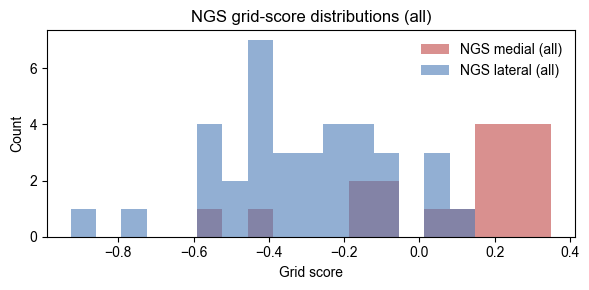

Overlapping grid-score range: [-0.584, 0.101]
Medial NGS: 20 -> 7 after trimming
Lateral NGS: 36 -> 34 after trimming


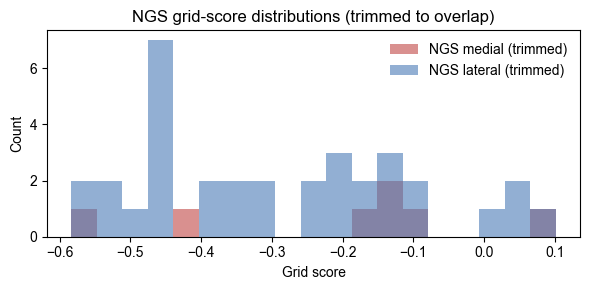

Grid-score matching (after trimming): 7 medial and 7 lateral NGS cells matched.


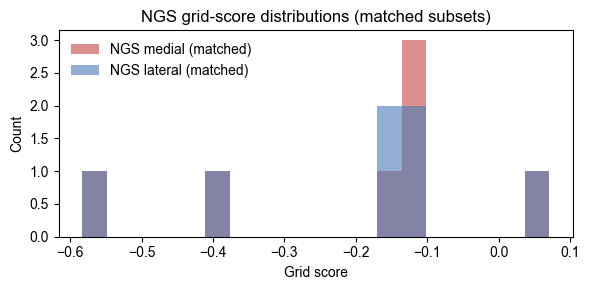

Covariate: ngs_medial_matched, pR2: 0.0606
Covariate: pos_ngs_medial_matched, pR2: 0.0786
Covariate: pos_ngs_medial_matched, pR2: 0.0786
Covariate: ngs_lateral_matched, pR2: 0.0374
Covariate: ngs_lateral_matched, pR2: 0.0374
Covariate: pos_ngs_lateral_matched, pR2: 0.0524
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_la

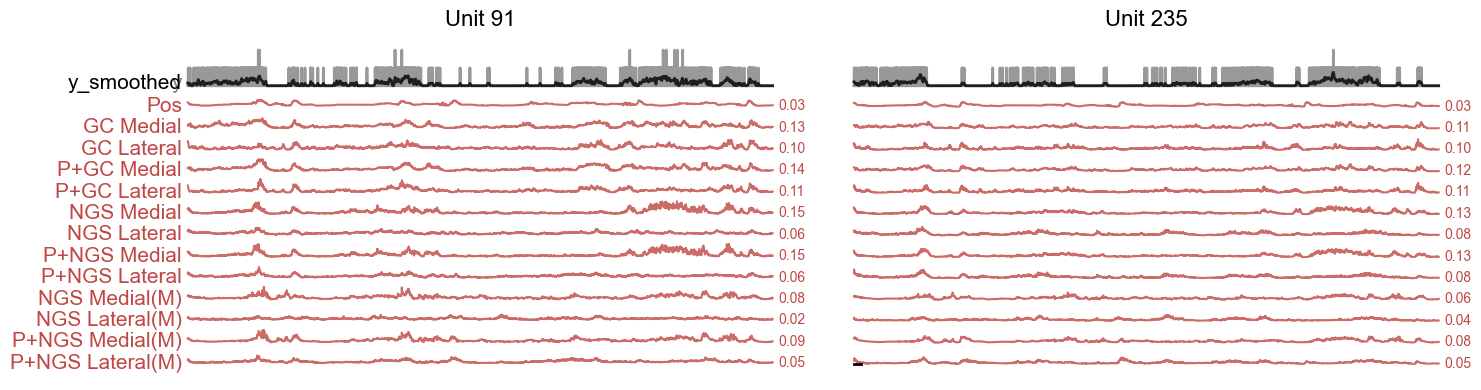

plot_xgboost_traces: Finished plotting


In [ ]:
# Ensure all['SC_x'] is positive before building the dictionary
if (all['SC_x'] < 0).any():
    all['SC_x'] = all['SC_x'].abs()

coord_SCs_x_dict = dict(zip(all['cluster_id'], all['SC_x']))

# Use the grid_score column (value at the optimal travel lag row)
ngs_grid_score_dict = {
    int(row["cluster_id"]): float(row["grid_score"])
    for _, row in ngs.iterrows()
    if pd.notnull(row["grid_score"])
}

print(f"Built ngs_grid_score_dict for {len(ngs_grid_score_dict)} NGS cells")

# For each test cell
results_dict = {}
for target_id in [test_grid_cell_1, test_grid_cell_2]:
    results_dict[target_id] = predict_xgboost_traces(
        target_id=target_id,
        tcs_time=tcs_time,
        pos_in_time=pos_in_time,
        grid_predictors=grid_predictors,
        ngs_predictors=ngs_predictors,
        coord_SCs_x_dict=coord_SCs_x_dict,
        xgb_history=xgb_history,
        gaussian_filter_nan=gaussian_filter_nan,
        ngs_grid_score_dict=ngs_grid_score_dict
    )

# To plot
plot_xgboost_traces(
    results_dict=results_dict,
    target_cell_names=[test_grid_cell_1, test_grid_cell_2],
    covariate_labels=[
        'pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral',
        'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral',
        'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched'
    ],
    tidy_covariate_labels=[
        'Pos', 'GC Medial', 'GC Lateral', 'P+GC Medial', 'P+GC Lateral',
        'NGS Medial', 'NGS Lateral', 'P+NGS Medial', 'P+NGS Lateral',
        'NGS Medial(GSM)', 'NGS Lateral(GSM)', 'P+NGS Medial(GSM)', 'P+NGS Lateral(GSM)'
    ],
    true_labels=['y', 'y_smoothed'],
    window=(24150, 28150),
    figsize=(15, 4),
    gain=[3,3],
    text_offset=0.0,
    offset_jump=0.0,
    savepath=None,
    time_bs=100
)

Plotting window 1: (24150, 28150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 

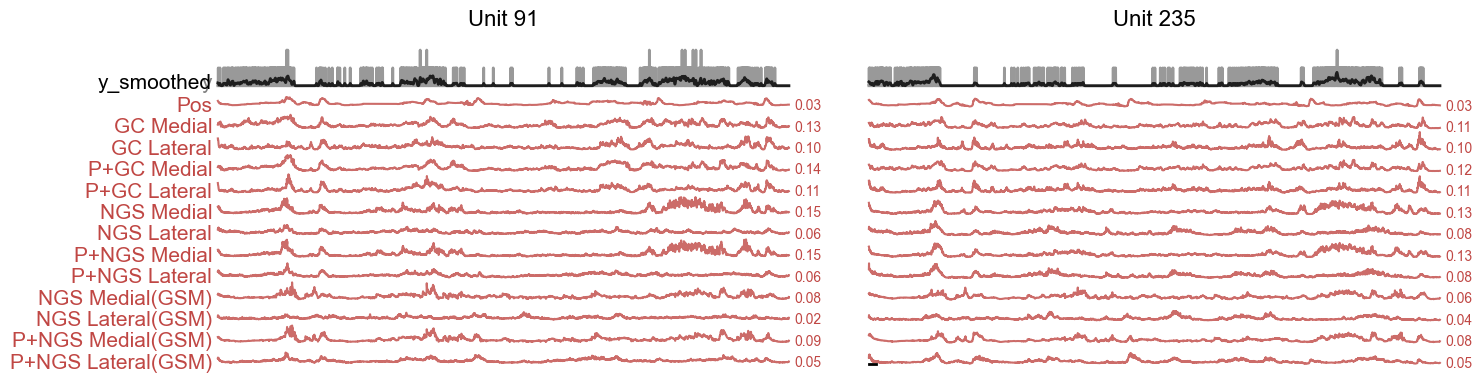

plot_xgboost_traces: Finished plotting
Plotting window 2: (25150, 29150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_m

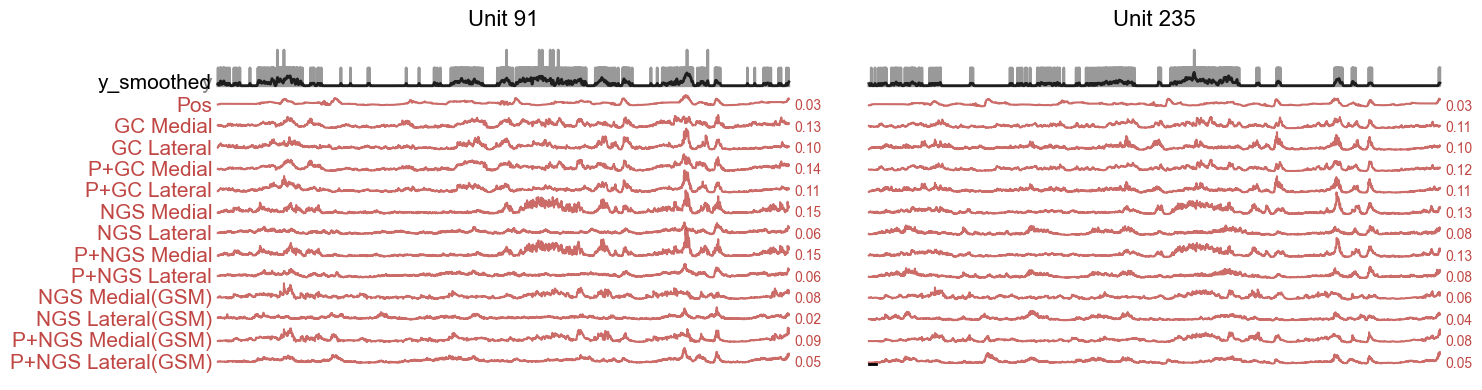

plot_xgboost_traces: Finished plotting
Plotting window 3: (26150, 30150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_m

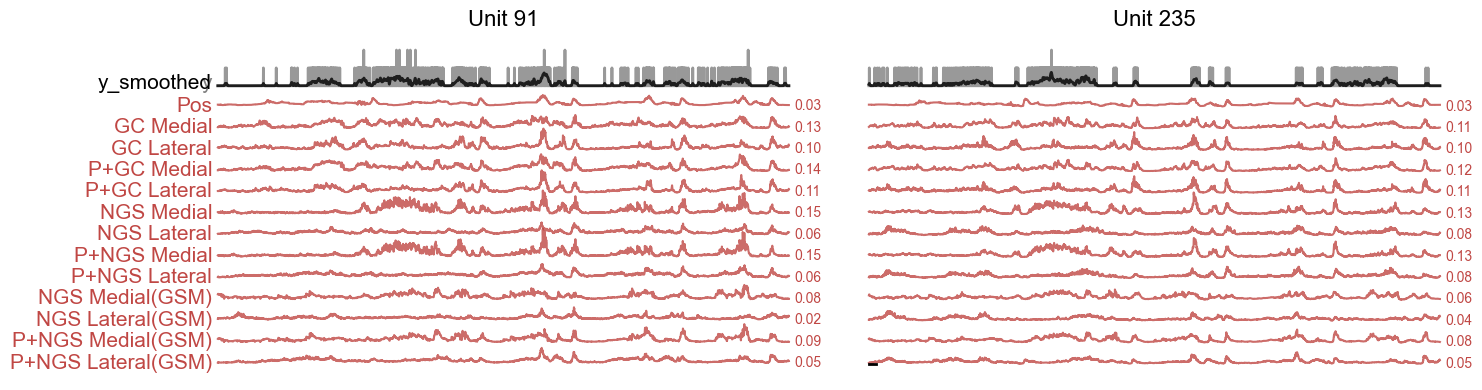

plot_xgboost_traces: Finished plotting
Plotting window 4: (27150, 31150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_m

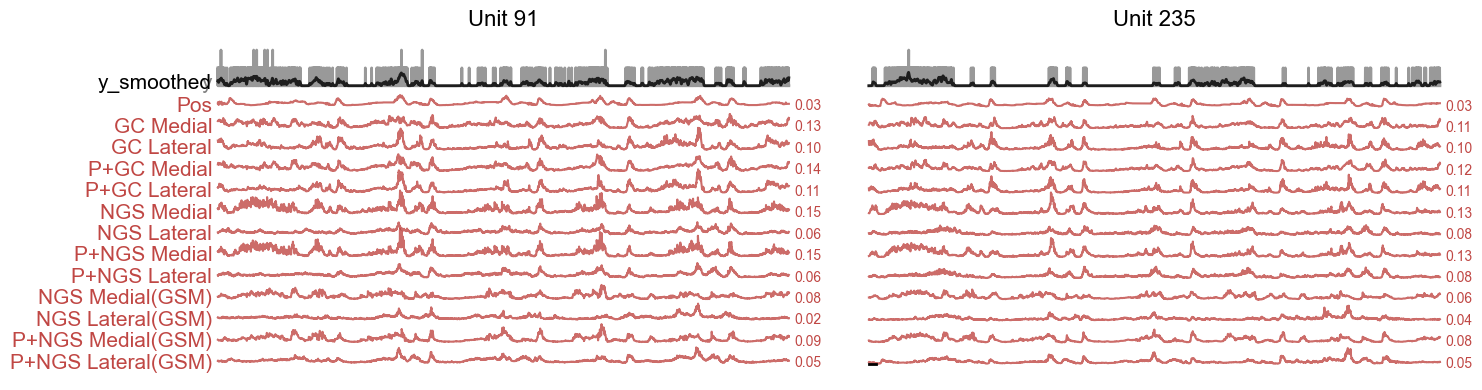

plot_xgboost_traces: Finished plotting
Plotting window 5: (28150, 32150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_m

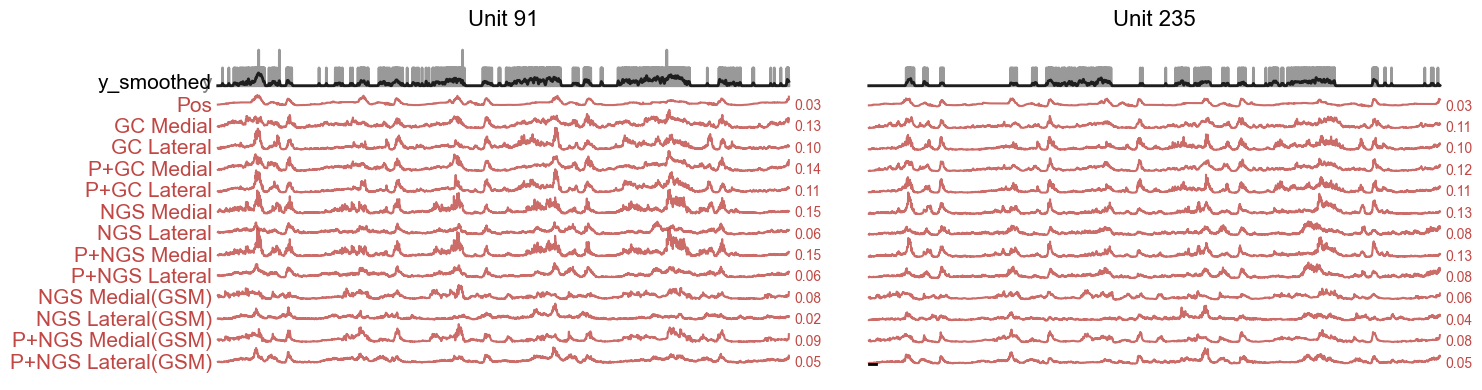

plot_xgboost_traces: Finished plotting
Plotting window 6: (29150, 33150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_m

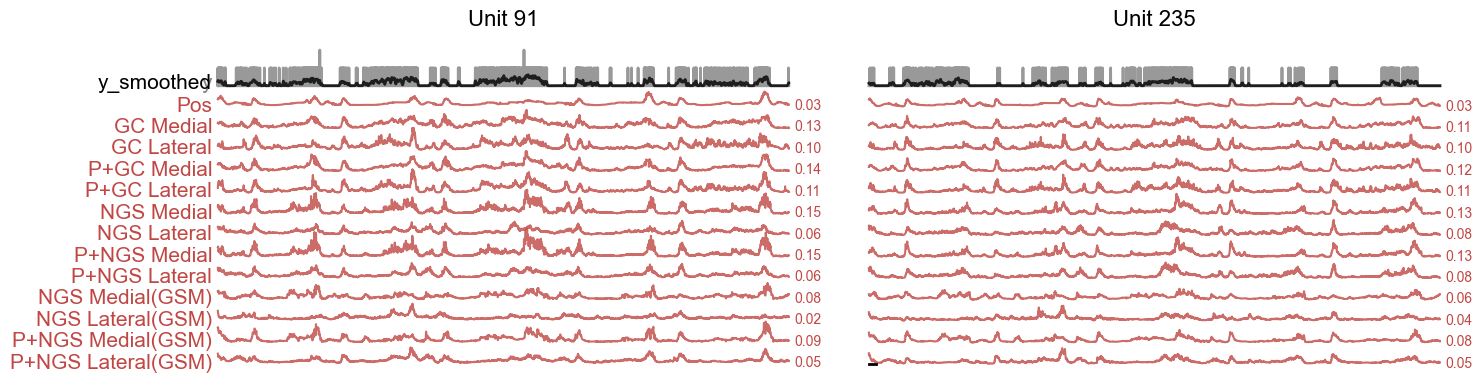

plot_xgboost_traces: Finished plotting
Plotting window 7: (30150, 34150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_m

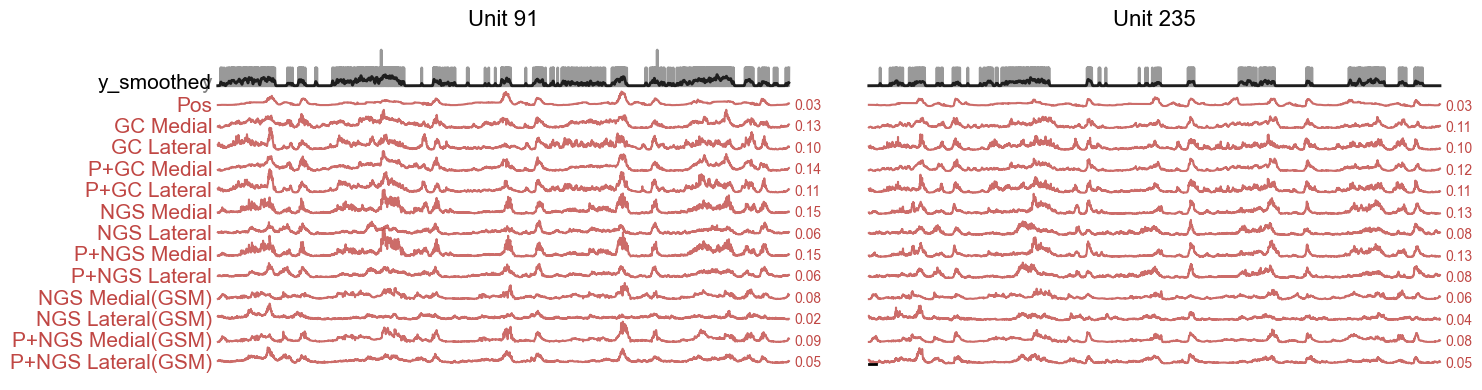

plot_xgboost_traces: Finished plotting
Plotting window 8: (31150, 35150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_m

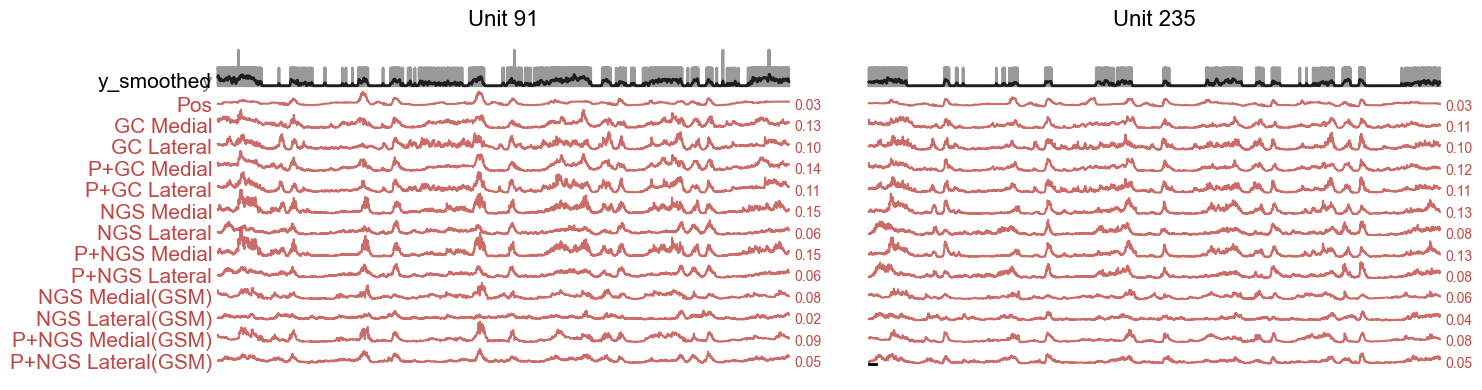

plot_xgboost_traces: Finished plotting
Plotting window 9: (32150, 36150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_m

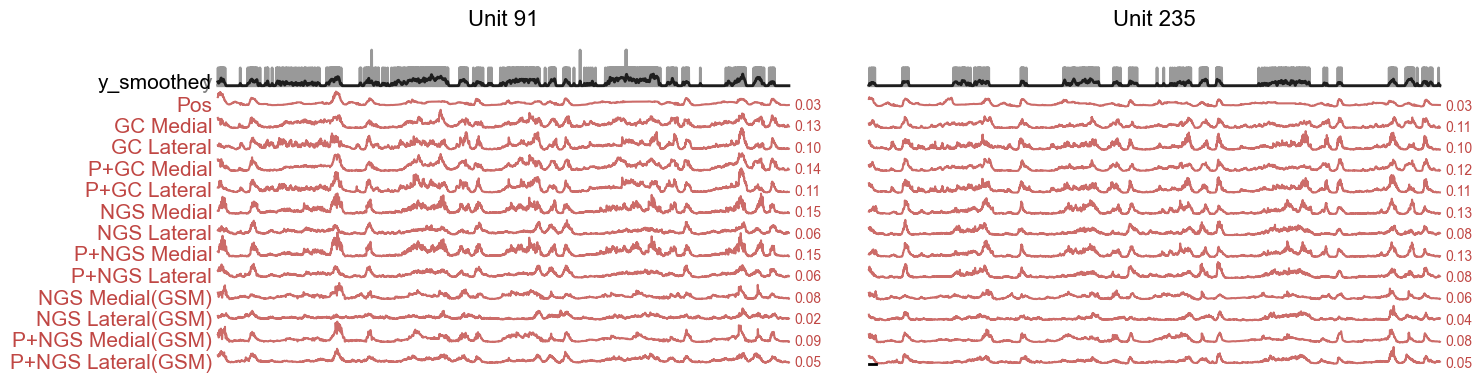

plot_xgboost_traces: Finished plotting
Plotting window 10: (33150, 37150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_

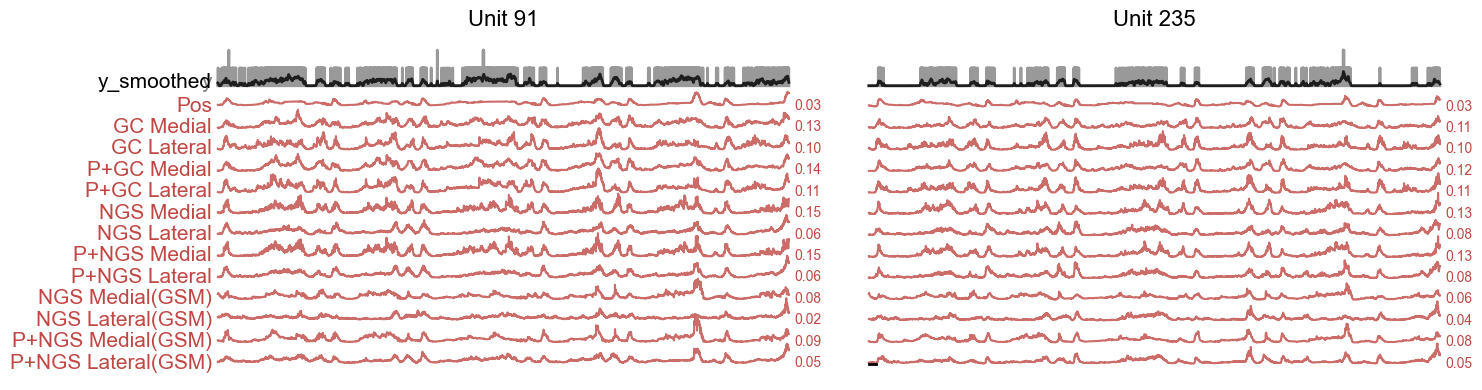

plot_xgboost_traces: Finished plotting
Plotting window 11: (34150, 38150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_

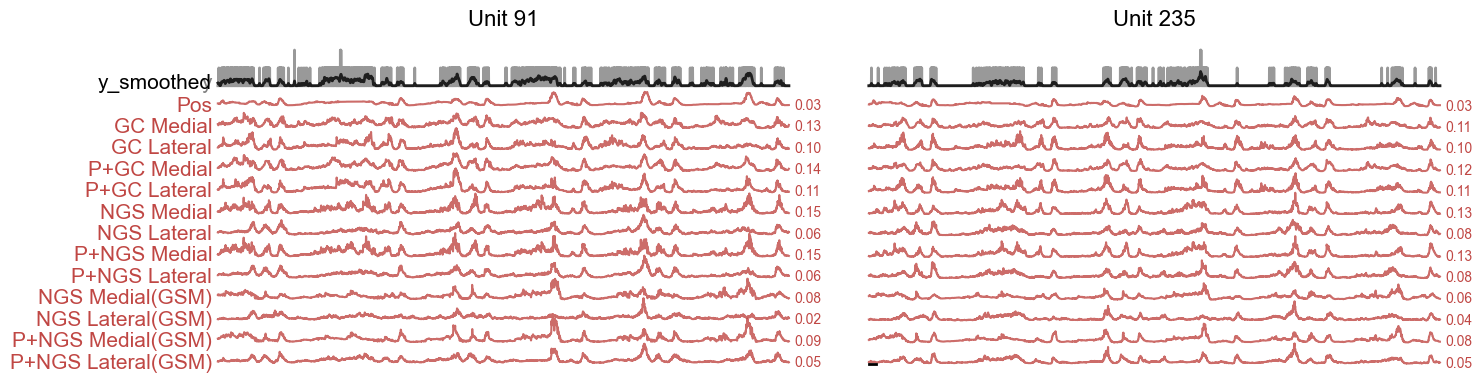

plot_xgboost_traces: Finished plotting
Plotting window 12: (35150, 39150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_

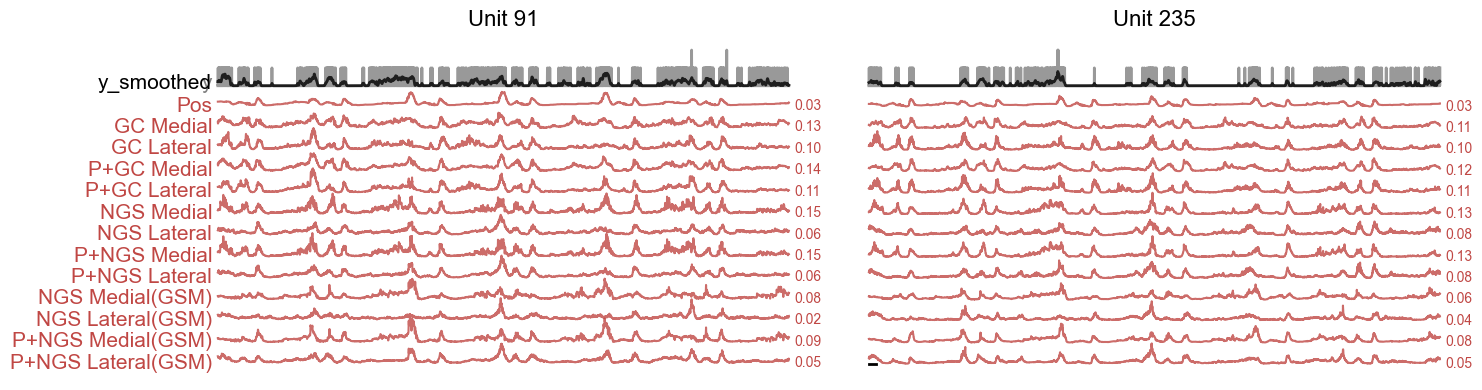

plot_xgboost_traces: Finished plotting
Plotting window 13: (36150, 40150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_

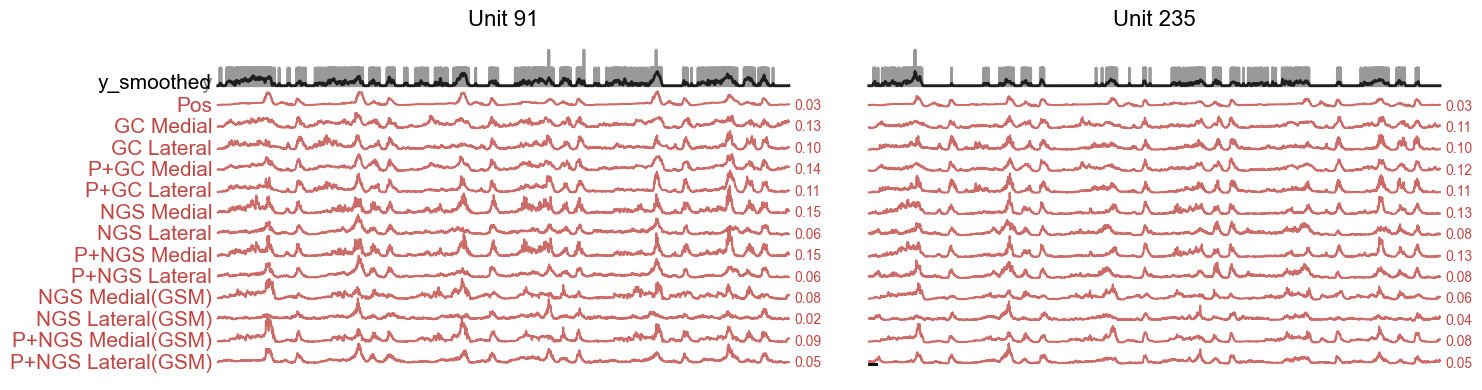

plot_xgboost_traces: Finished plotting
Plotting window 14: (37150, 41150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_

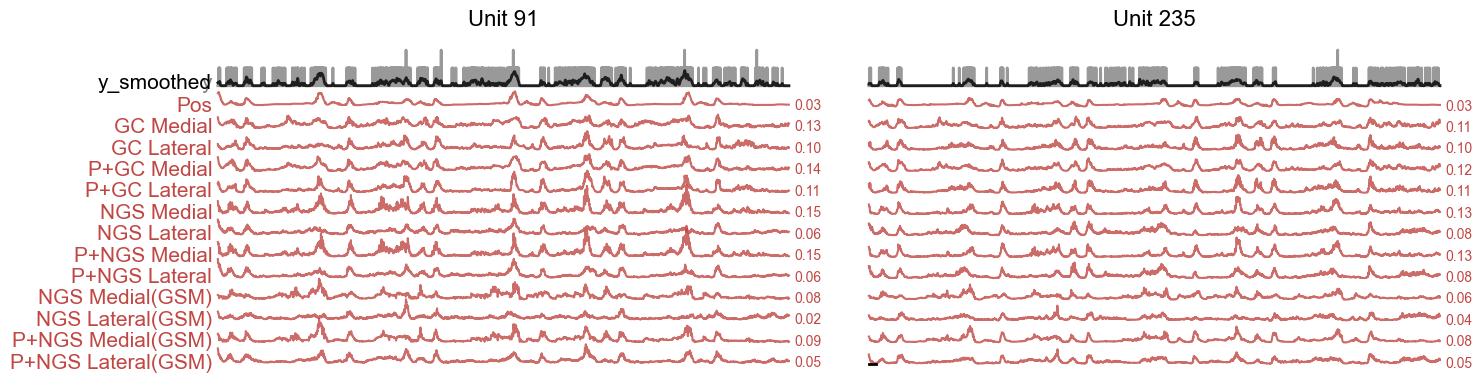

plot_xgboost_traces: Finished plotting
Plotting window 15: (38150, 42150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_

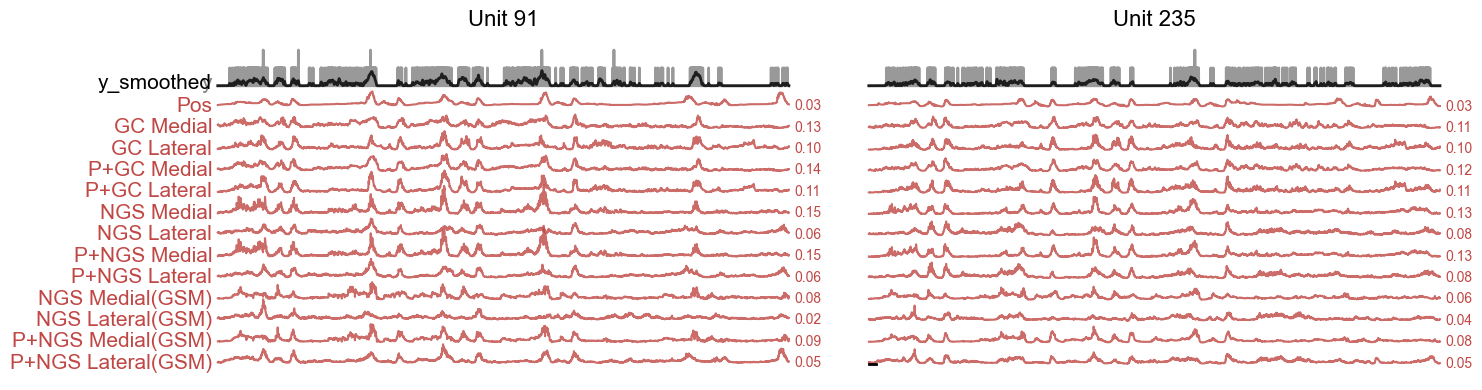

plot_xgboost_traces: Finished plotting
Plotting window 16: (39150, 43150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_

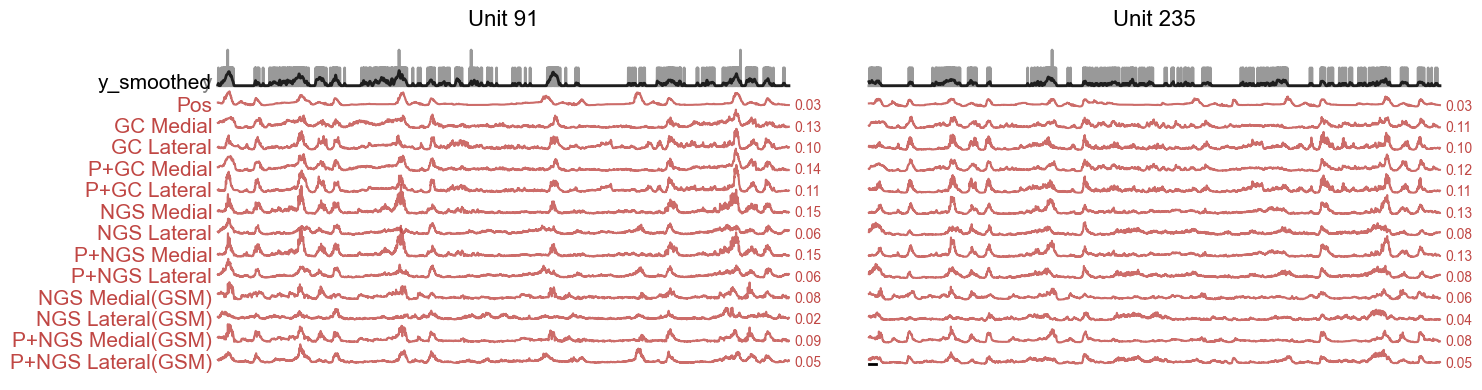

plot_xgboost_traces: Finished plotting
Plotting window 17: (40150, 44150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_

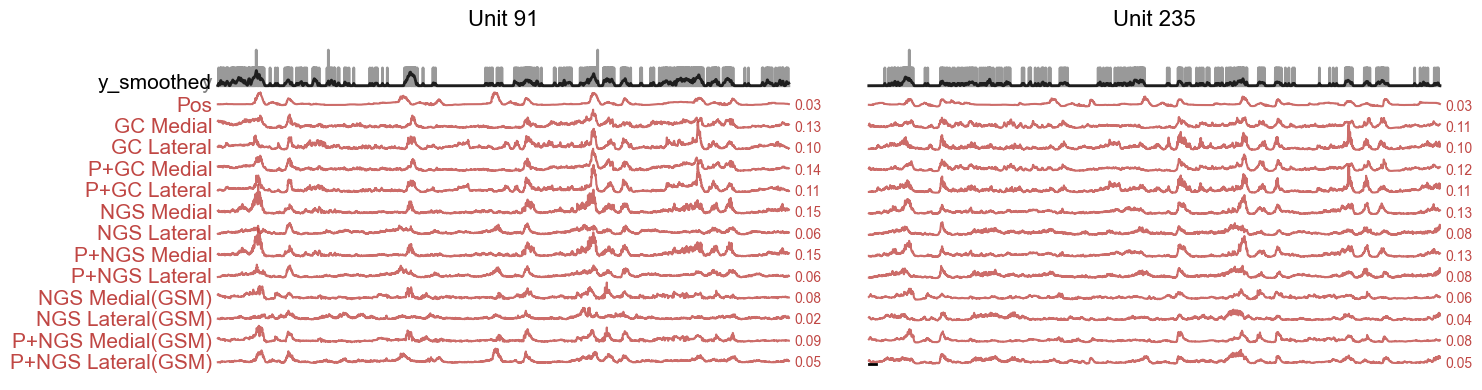

plot_xgboost_traces: Finished plotting
Plotting window 18: (41150, 45150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_

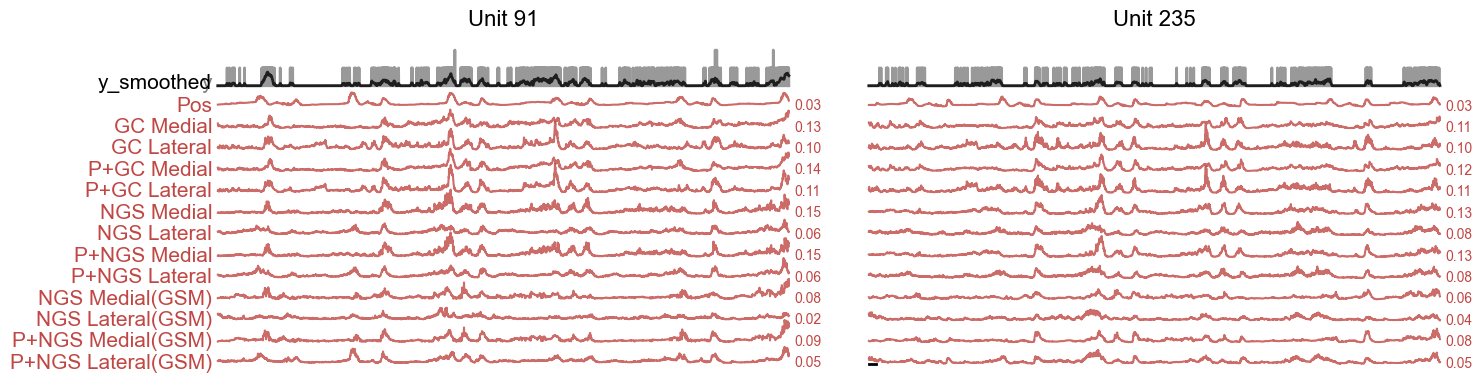

plot_xgboost_traces: Finished plotting
Plotting window 19: (42150, 46150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_

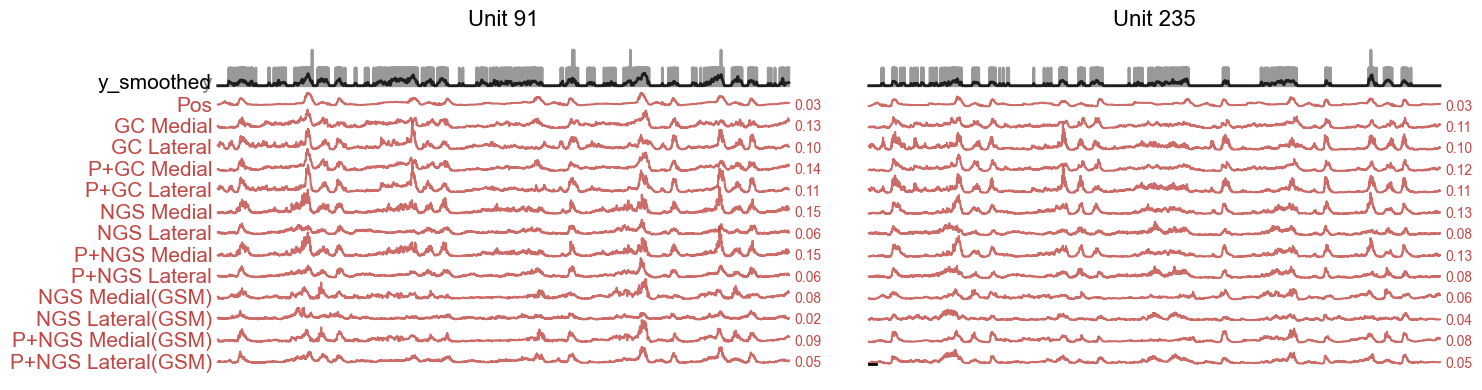

plot_xgboost_traces: Finished plotting
Plotting window 20: (43150, 47150)
plot_xgboost_traces: Start plotting
Target cells: [91, 235]
Covariate labels: ['pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral', 'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral', 'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched']
Results dict keys for each cell:
  91: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
  235: ['pos', 'g_medial', 'pos_g_medial', 'g_lateral', 'pos_g_lateral', 'ngs_medial', 'pos_ngs_medial', 'ngs_lateral', 'pos_ngs_lateral', 'ngs_medial_matched', 'pos_ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_lateral_matched', 'y', 'y_smoothed']
Ordered labels for plotting: ['y', 'pos', 'g_medial', 'g_lateral', 'pos_g_

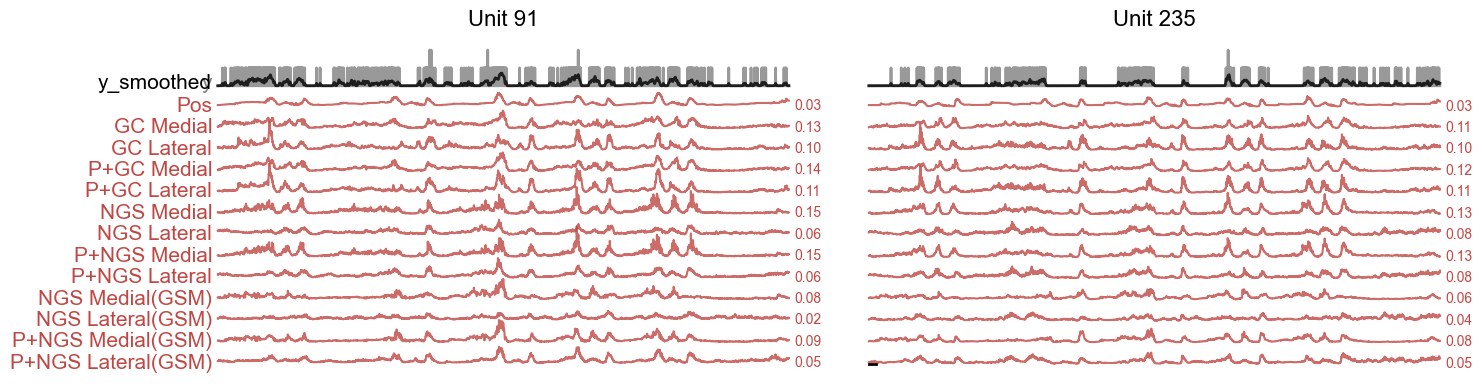

plot_xgboost_traces: Finished plotting


In [36]:
# Define 20 example windows of length 2000, spaced by 1000 (overlapping by 1000)
window_starts = [24150 + i * 1000 for i in range(20)]
window_length = 4000

for idx, start in enumerate(window_starts):
    end = start + window_length
    print(f"Plotting window {idx+1}: ({start}, {end})")
    plot_xgboost_traces(
        results_dict=results_dict,
        target_cell_names=[test_grid_cell_1, test_grid_cell_2],
        covariate_labels=[
            'pos', 'g_medial', 'g_lateral', 'pos_g_medial', 'pos_g_lateral',
            'ngs_medial', 'ngs_lateral', 'pos_ngs_medial', 'pos_ngs_lateral',
            'ngs_medial_matched', 'ngs_lateral_matched', 'pos_ngs_medial_matched', 'pos_ngs_lateral_matched'
        ],
        tidy_covariate_labels=[
            'Pos', 'GC Medial', 'GC Lateral', 'P+GC Medial', 'P+GC Lateral',
            'NGS Medial', 'NGS Lateral', 'P+NGS Medial', 'P+NGS Lateral',
            'NGS Medial(GSM)', 'NGS Lateral(GSM)', 'P+NGS Medial(GSM)', 'P+NGS Lateral(GSM)'
        ],
        true_labels=['y', 'y_smoothed'],
        window=(start, end),
        figsize=(15, 4),
        gain=[4,5],
        text_offset=0.0,
        offset_jump=0.0,
        savepath=f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_medial_lateral_xgboost_traces_window{idx+1}.pdf',
        time_bs=100
    )